<a href="https://colab.research.google.com/github/JustinZ-17/segregation_reproduction/blob/main/dinov2_pspnet_voc_reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from huggingface_hub import login
login()  # 会要求输入 HuggingFace token；如果不想交互，可改为 login(token="hf_xxx")

In [5]:
!nvidia-smi
import torch
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


Sat Sep 12 06:54:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!pip install -q -U transformers accelerate
!pip install -q matplotlib tqdm
#安装依赖

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 33.6 MB/s eta 0:00:00


In [7]:
import os
import tarfile
import urllib.request

data_root = "./data"
os.makedirs(data_root, exist_ok=True)

voc_url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"
tar_path = os.path.join(data_root, "VOCtrainval_11-May-2012.tar")

if not os.path.exists(os.path.join(data_root, "VOCdevkit", "VOC2012")):
    print("Downloading PASCAL VOC 2012 (~2GB) ...")
    urllib.request.urlretrieve(voc_url, tar_path)
    print("Extracting...")
    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(data_root)
    print("Done")
else:
    print("PASCAL VOC 2012 already exists.")
#下载数据集

Extracting...


/tmp/ipykernel_2052/3821637749.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_root)


Done


In [11]:
from torchvision import transforms
from torchvision.datasets import VOCSegmentation
from torch.utils.data import DataLoader

input_size = 224
num_classes = 21
ignore_index = 255

img_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

mask_transform = transforms.Compose([
    transforms.Resize((input_size, input_size), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
    transforms.Lambda(lambda x: x.squeeze().long()),
])

train_ds = VOCSegmentation(
    root=data_root, year="2012", image_set="train", download=False,
    transform=img_transform, target_transform=mask_transform)
val_ds = VOCSegmentation(
    root=data_root, year="2012", image_set="val", download=False,
    transform=img_transform, target_transform=mask_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")


Train: 1464 | Val: 1449


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

class DINOv2Backbone(nn.Module):
    def __init__(self, model_name="facebook/dinov2-small"):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)
        self.patch_size = 14  # DINOv2 是 14×14 patch
        for p in self.model.parameters():
            p.requires_grad = False
        self.model.eval()

    def forward(self, x):
        B, C, H, W = x.shape
        h, w = H // self.patch_size, W // self.patch_size
        out = self.model(x)
        tokens = out.last_hidden_state  # (B, 1 + h*w, 384)
        # DINOv2 布局：第 0 个是 CLS，其余是 patch tokens
        patch_tokens = tokens[:, 1:, :]
        patch_tokens = patch_tokens.transpose(1, 2).reshape(B, -1, h, w)
        return patch_tokens

    def train(self, mode=True):
        super().train(False)
        return self


class PSPHead(nn.Module):
    def __init__(self, in_channels, num_classes, pool_sizes=(1, 2, 3, 6), out_channels=512):
        super().__init__()
        self.stages = nn.ModuleList()
        reduce_dim = in_channels // len(pool_sizes)
        for size in pool_sizes:
            self.stages.append(nn.Sequential(
                nn.AdaptiveAvgPool2d(output_size=size),
                nn.Conv2d(in_channels, reduce_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(reduce_dim),
                nn.ReLU(inplace=True),
            ))
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels + len(pool_sizes) * reduce_dim, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Conv2d(out_channels, num_classes, kernel_size=1),
        )

    def forward(self, features, input_size):
        h, w = features.shape[2:]
        pyramids = [features]
        for stage in self.stages:
            x = stage(features)
            x = F.interpolate(x, size=(h, w), mode="bilinear", align_corners=False)
            pyramids.append(x)
        x = torch.cat(pyramids, dim=1)
        x = self.bottleneck(x)
        x = F.interpolate(x, size=input_size, mode="bilinear", align_corners=False)
        return x


class DINOv2_PSPNet(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()
        self.backbone = DINOv2Backbone()
        self.head = PSPHead(in_channels=384, num_classes=num_classes)

    def forward(self, x):
        input_size = x.shape[2:]
        features = self.backbone(x)
        out = self.head(features, input_size)
        return out


In [15]:
cfg = {
    "num_classes": 21,
    "ignore_index": 255,
    "input_size": 224,
    "batch_size": 8,
    "epochs": 20,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

model = DINOv2_PSPNet(num_classes=cfg["num_classes"]).to(cfg["device"])
criterion = nn.CrossEntropyLoss(ignore_index=cfg["ignore_index"])
optimizer = torch.optim.AdamW(model.head.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

print(f"Backbone frozen params: {sum(p.numel() for p in model.backbone.parameters())/1e6:.1f}M")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M")


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Backbone frozen params: 22.1M
Trainable params: 3.7M


In [16]:
import numpy as np
from tqdm.auto import tqdm

def compute_iou(pred, target, num_classes, ignore_index=255):
    pred = pred.detach().argmax(1).cpu().numpy()
    target = target.cpu().numpy()
    ious = []
    for c in range(num_classes):
        pred_c = pred == c
        target_c = target == c
        valid = target != ignore_index
        inter = np.logical_and(pred_c, target_c).sum()
        union = np.logical_or(pred_c & valid, target_c).sum()
        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(inter / union)
    return float(np.nanmean(ious))

def compute_pixel_acc(pred, target, ignore_index=255):
    pred = pred.detach().argmax(1).cpu().numpy()
    target = target.cpu().numpy()
    valid = target != ignore_index
    return float((pred[valid] == target[valid]).sum() / valid.sum())

@torch.no_grad()
def validate(model, loader, criterion, device, num_classes, ignore_index):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    total_acc = 0.0
    for images, masks in tqdm(loader, desc="Validate"):
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss = criterion(logits, masks)
        total_loss += loss.item() * images.size(0)
        total_iou += compute_iou(logits, masks, num_classes, ignore_index) * images.size(0)
        total_acc += compute_pixel_acc(logits, masks, ignore_index) * images.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_iou / n, total_acc / n

def train_one_epoch(model, loader, criterion, optimizer, device, num_classes, ignore_index):
    model.train()
    total_loss = 0.0
    for images, masks in tqdm(loader, desc="Train"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


In [17]:
os.makedirs("results", exist_ok=True)
history = {"train_loss": [], "val_loss": [], "val_miou": [], "val_acc": []}
best_miou = -1.0

for epoch in range(1, cfg["epochs"] + 1):
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer,
        cfg["device"], cfg["num_classes"], cfg["ignore_index"])
    val_loss, val_miou, val_acc = validate(
        model, val_loader, criterion,
        cfg["device"], cfg["num_classes"], cfg["ignore_index"])
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_mIoU={val_miou:.4f} | val_pixAcc={val_acc:.4f}")

    if val_miou > best_miou:
        best_miou = val_miou
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.head.state_dict(),
            "cfg": cfg,
            "best_miou": best_miou,
        }, "results/best_head.pth")
        print(f"  -> Best model saved (mIoU={best_miou:.4f})")


Train:   0%|          | 0/183 [00:00<?, ?it/s]

Validate:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 01: train_loss=0.3989 | val_loss=0.2211 | val_mIoU=0.5643 | val_pixAcc=0.9197
  -> Best model saved (mIoU=0.5643)


Train:   0%|          | 0/183 [00:00<?, ?it/s]

Validate:   0%|          | 0/182 [00:00<?, ?it/s]

...

Validate:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 19: train_loss=0.0486 | val_loss=0.1421 | val_mIoU=0.6743 | val_pixAcc=0.9515
  -> Best model saved (mIoU=0.6743)


Train:   0%|          | 0/183 [00:00<?, ?it/s]

Validate:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 20: train_loss=0.0487 | val_loss=0.1432 | val_mIoU=0.6728 | val_pixAcc=0.9513


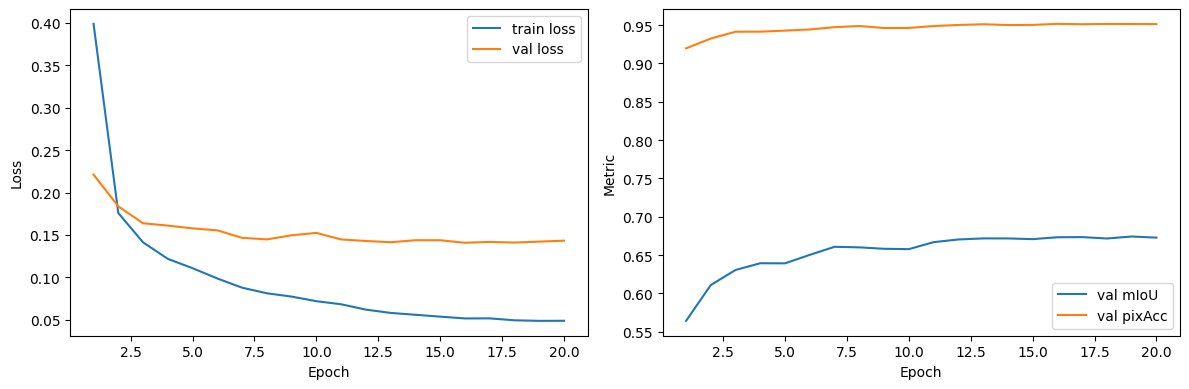

In [18]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train loss")
axes[0].plot(epochs, history["val_loss"], label="val loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, history["val_miou"], label="val mIoU")
axes[1].plot(epochs, history["val_acc"], label="val pixAcc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=150)
plt.show()


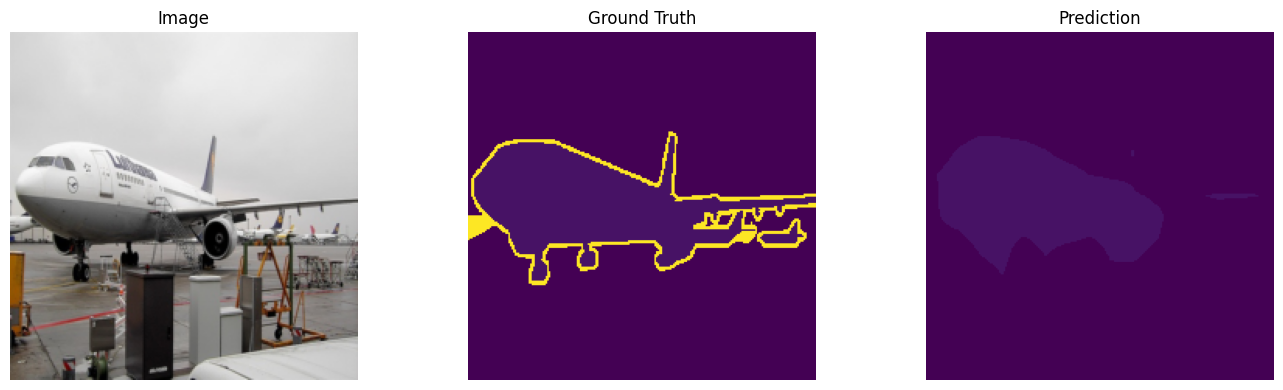

In [19]:
import numpy as np
from PIL import Image

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

model.eval()
images, masks = next(iter(val_loader))
images = images.to(cfg["device"])
with torch.no_grad():
    preds = model(images).argmax(1).cpu()

idx = 0
img = denormalize(images[idx].cpu()).permute(1, 2, 0).numpy()
img = np.clip(img, 0, 1)
pred = preds[idx].numpy()
mask = masks[idx].numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img)
axes[0].set_title("Image")
axes[1].imshow(mask, vmin=0, vmax=20)
axes[1].set_title("Ground Truth")
axes[2].imshow(pred, vmin=0, vmax=20)
axes[2].set_title("Prediction")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("results/sample_prediction.png", dpi=150)
plt.show()


In [20]:
from google.colab import drive
drive.mount("/content/drive")

save_dir = "/content/drive/MyDrive/DINOv3_PSPNet_VOC"
os.makedirs(save_dir, exist_ok=True)
import shutil
shutil.copytree("results", os.path.join(save_dir, "results"), dirs_exist_ok=True)
print("Saved to", save_dir)


Mounted at /content/drive
Saved to /content/drive/MyDrive/DINOv3_PSPNet_VOC


In [21]:
!zip -r results.zip results/

from google.colab import files
files.download("results.zip")


  adding: results/ (stored 0%)
  adding: results/training_curves.png (deflated 12%)
  adding: results/best_head.pth (deflated 7%)
  adding: results/sample_prediction.png (deflated 2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>